# 02_feature_engineering_and_train.ipynb

이 노트북은 전처리된 택시 수요 데이터를 로드하여 Feature Engineering을 수행하고, LightGBM 모델을 학습시킨 후 ONNX 형식으로 내보냅니다.

## 1. 필요한 라이브러리 임포트

In [1]:
import polars as pl
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime

# ONNX 관련 라이브러리
from onnxmltools import convert_lightgbm
from skl2onnx.common.data_types import FloatTensorType, Int64TensorType


## 2. 전처리된 데이터 로드

이전 단계에서 저장한 `aggregated_demand.parquet` 파일을 로드합니다.

In [2]:
processed_data_path = "../data/processed/aggregated_demand.parquet"

if not os.path.exists(processed_data_path):
    raise FileNotFoundError(f"Data not found at {processed_data_path}")

df = pl.read_parquet(processed_data_path)

# [수정 1] 데이터 타입 최적화 (PULocationID를 Int32로, demand를 Float32로)
df = df.with_columns([
    pl.col("PULocationID").cast(pl.Int32),
    pl.col("demand").cast(pl.Float32) # 모델링을 위해 Float로 변환
])

In [3]:
# 시간 특징
df = df.with_columns(
    pl.col("pickup_time").dt.hour().cast(pl.Int32).alias("hour"),
    pl.col("pickup_time").dt.weekday().cast(pl.Int32).alias("day_of_week"),
    ((pl.col("pickup_time").dt.weekday() >= 6).cast(pl.Int32)).alias("is_weekend")
)

# Lag Features (PULocationID 별로 계산)
# shift(1) = 직전 15분, shift(4) = 1시간 전
df = df.with_columns([
    pl.col("demand").shift(1).over("PULocationID").alias("demand_lag_1"),
    pl.col("demand").shift(4).over("PULocationID").alias("demand_lag_4"),
    pl.col("demand").shift(96).over("PULocationID").alias("demand_lag_96"),
    pl.col("demand").rolling_mean(window_size=4, min_periods=1).over("PULocationID").alias("rolling_mean_4")
]).fill_null(0.0)

# [Target 생성] 15분 뒤의 수요 (반드시 Upsampling 후에 해야 정확함)
df = df.with_columns(
    pl.col("demand").shift(-1).over("PULocationID").alias("target")
)

# 마지막 행(Target이 Null) 제거
df = df.filter(pl.col("target").is_not_null())

/var/folders/hv/y2yg6cw53bx_m5g2sh5sfc2w0000gp/T/ipykernel_12878/3604355553.py:14: DeprecationWarning: the argument `min_periods` for `Expr.rolling_mean` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  pl.col("demand").rolling_mean(window_size=4, min_periods=1).over("PULocationID").alias("rolling_mean_4")


## 4. 데이터 분할 (Time-based Split)

시계열 데이터의 특성상 절대로 셔플(shuffle)하지 않고, 시간을 기준으로 훈련/테스트 데이터를 분할합니다.
-   **훈련 데이터**: 2024년 12월 31일 이전 데이터
-   **테스트 데이터**: 2025년 1월 1일 이후 데이터

In [4]:
# [수정 2] 2024년 12월 31일 23:59:59까지 포함하도록 수정
split_date = datetime(2025, 1, 1)

train_df = df.filter(pl.col("pickup_time") < split_date)
test_df = df.filter(pl.col("pickup_time") >= split_date)

print(f"Train samples: {len(train_df):,}")
print(f"Test samples:  {len(test_df):,}")

features = ["PULocationID", "hour", "day_of_week", "is_weekend", 
            "demand_lag_1", "demand_lag_4", "demand_lag_96", "rolling_mean_4"]
target = "target"

# LightGBM용 데이터 준비 (Polars -> Pandas 변환 없이 사용 가능하지만, ONNX 타입 맞추기 위해 사전 처리)
X_train = train_df.select(features)
y_train = train_df.select(target).to_series()
X_test = test_df.select(features)
y_test = test_df.select(target).to_series()

Train samples: 18,167,349
Test samples:  8,228,297


## 5. LightGBM 모델 학습

LightGBM Regressor를 사용하여 모델을 학습시킵니다.
`PULocationID`는 범주형 특징으로 처리합니다.

In [5]:
lgbm = lgb.LGBMRegressor(
    objective='mae', 
    n_estimators=1000, 
    learning_rate=0.05, 
    num_leaves=31, 
    random_state=42
)

categorical_feats = ["PULocationID", "hour", "day_of_week", "is_weekend"]

print("Training started...")
lgbm.fit(
    X_train.to_pandas(), y_train.to_pandas(),
    categorical_feature=categorical_feats,
    eval_set=[(X_test.to_pandas(), y_test.to_pandas())],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(50)]
)

Training started...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.401974 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 996
[LightGBM] [Info] Number of data points in the train set: 18167349, number of used features: 8
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l1: 0.975332


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'mae'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 6. 모델 평가 및 시각화

테스트 셋에 대한 MAE와 RMSE를 계산하고, 실제값과 예측값을 시각화하여 모델 성능을 확인합니다.

Making predictions on the test set...

--- Model Evaluation ---
Mean Absolute Error (MAE): 0.9753
Root Mean Squared Error (RMSE): 3.2819

Generating visualization for PULocationID 132 from 2025-01-01 to 2025-01-08...


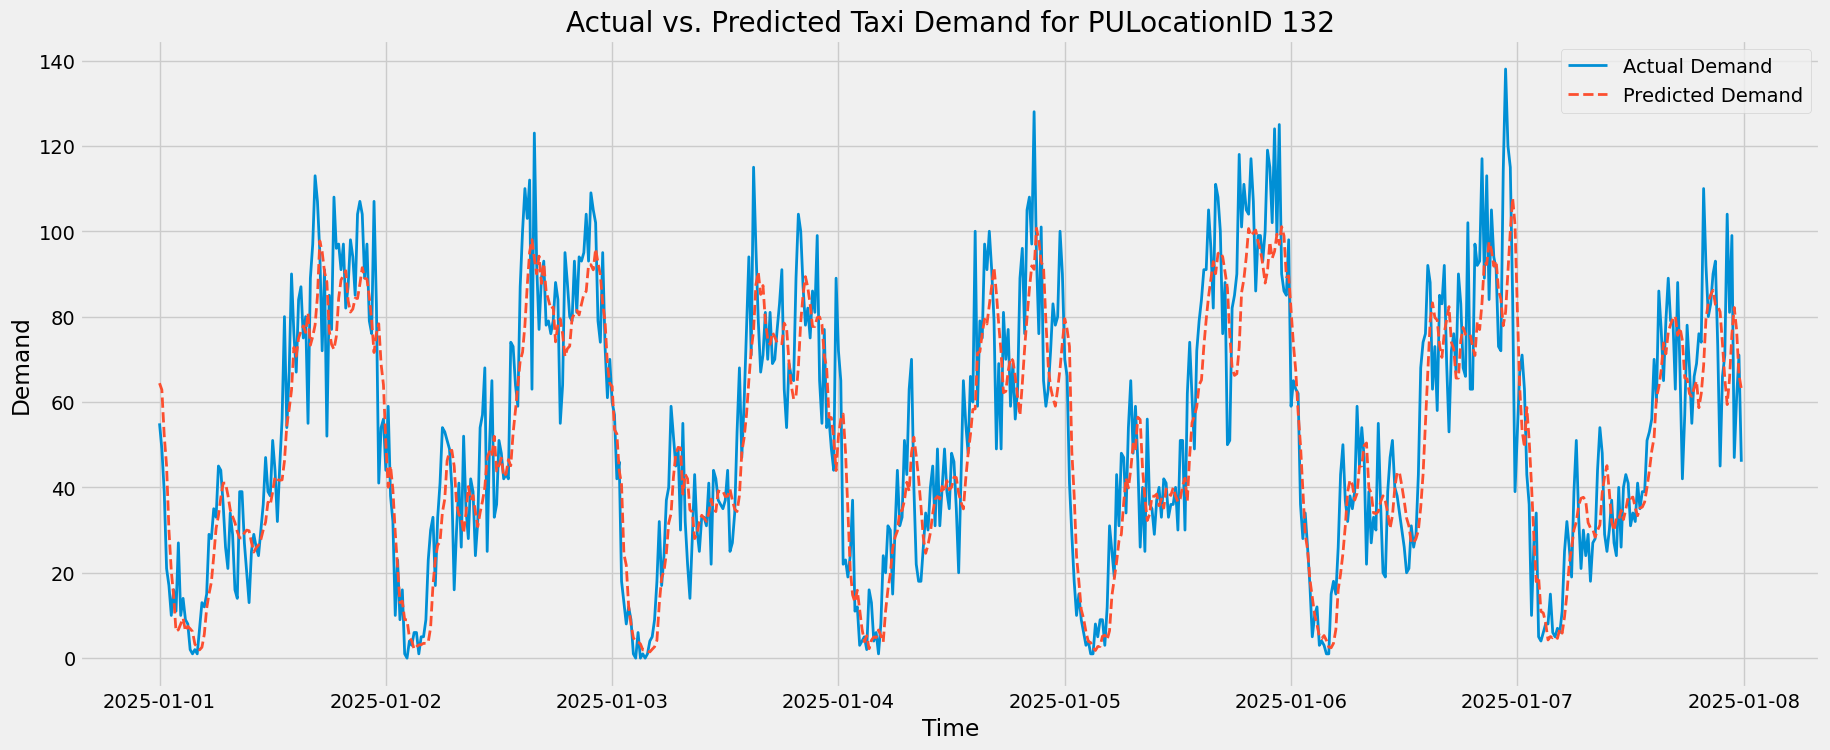

In [6]:
# 1. 테스트 데이터셋에 대한 예측 수행
print("Making predictions on the test set...")
y_pred = lgbm.predict(X_test.to_pandas())

# 2. 모델 성능 평가 (MAE, RMSE)
mae = mean_absolute_error(y_test.to_pandas(), y_pred)
# RMSE는 MSE의 제곱근입니다.
rmse = np.sqrt(mean_squared_error(y_test.to_pandas(), y_pred))

print("\n--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}\n")

# 3. 시각화를 위한 데이터 준비
# 전체 데이터는 너무 크므로, 샘플을 추출하여 시각화합니다.
# 예측 결과를 기존 테스트 데이터프레임에 합칩니다.
# test_df와 y_pred는 행의 순서가 동일하다고 가정합니다.
results_df = test_df.with_columns(
    pl.Series(name="predicted_demand", values=y_pred)
    )

# 시각화할 특정 지역(PULocationID)과 기간을 정의합니다.
# 예시: PULocationID 132 (라과디아 공항)의 2025년 1월 첫 7일
location_to_plot = 132
start_date = datetime(2025, 1, 1)
end_date = datetime(2025, 1, 8)

sample_vis_df = results_df.filter(
    (pl.col("PULocationID") == location_to_plot) &
    (pl.col("pickup_time") >= start_date) &
    (pl.col("pickup_time") < end_date)
    )
print(f"Generating visualization for PULocationID {location_to_plot} from {start_date.date()} to {end_date.date()}...")

# 4. Matplotlib을 사용한 시각화
plt.style.use('fivethirtyeight')
fig, ax = plt.subplots(figsize=(20, 8))
ax.plot(sample_vis_df["pickup_time"], sample_vis_df["target"], label="Actual Demand", linewidth=2)
ax.plot(sample_vis_df["pickup_time"], sample_vis_df["predicted_demand"], label="Predicted Demand", linestyle='--', linewidth=2)

ax.set_title(f"Actual vs. Predicted Taxi Demand for PULocationID {location_to_plot}")
ax.set_xlabel("Time")
ax.set_ylabel("Demand")
ax.legend()
plt.grid(True)
plt.show()

## 7. ONNX 모델로 내보내기

학습된 LightGBM 모델을 ONNX 형식으로 변환하여 `models/taxi_demand_model.onnx`로 저장합니다.

ONNX 모델로 변환 시, 모델의 입력 스키마(데이터 타입과 형태)를 정확히 지정하는 것이 중요합니다.

In [8]:
print("Exporting to ONNX for Flink...")

# [수정 3] Flink 서빙을 위해 모든 입력을 'float_input'이라는 하나의 배열로 받도록 설정
# Java에서: float[] input = {zone_id, hour, ...}; 형태로 주입 가능
n_features = len(features)
initial_types = [('float_input', FloatTensorType([None, n_features]))]

# ONNX 변환
onnx_model = convert_lightgbm(
    lgbm, 
    initial_types=initial_types, 
    target_opset=13
)

# 메타데이터에 피처 순서 저장 (나중에 Java에서 순서 확인할 때 유용)
meta = onnx_model.metadata_props.add()
meta.key = "feature_names"
meta.value = ",".join(features)

save_path = "../models/taxi_demand_model.onnx"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

with open(save_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"SUCCESS: Model saved to {save_path}")
print(f"Input Features Order for Flink: {features}")

Exporting to ONNX for Flink...
SUCCESS: Model saved to ../models/taxi_demand_model.onnx
Input Features Order for Flink: ['PULocationID', 'hour', 'day_of_week', 'is_weekend', 'demand_lag_1', 'demand_lag_4', 'demand_lag_96', 'rolling_mean_4']


## 8. ONNX 모델 검증 (선택 사항)

저장된 ONNX 모델이 올바르게 로드되고 예측을 수행하는지 간단히 확인합니다. `onnxruntime`이 필요합니다.

In [ ]:
try:
    import onnxruntime as rt

    sess = rt.InferenceSession(onnx_model_path)
    input_name = sess.get_inputs()[0].name
    output_name = sess.get_outputs()[0].name

    # 테스트 데이터의 일부를 사용하여 ONNX 모델로 예측
    # 입력 데이터는 ONNX 모델이 기대하는 형태로 변환해야 합니다.
    # LightGBM의 경우, FloatTensorType([None, num_features]) 형태의 단일 입력을 가정할 수 있습니다.
    
    # onnxmltools.convert_lightgbm 은 개별 피처를 명시적으로 전달하는 방식도 지원합니다.
    # initial_type_flat 에 맞춰 입력 딕셔너리를 구성해야 합니다.
    
    # 예시: 단일 예측을 위한 입력 준비
    sample_input = X_test.head(1)
    onnx_input_dict = {}
    for name in feature_names_for_onnx:
        if sample_input[name].dtype == pl.Float64 or sample_input[name].dtype == pl.Float32:
            onnx_input_dict[name] = sample_input[name].to_numpy().reshape(1, 1).astype(np.float32)
        else:
            onnx_input_dict[name] = sample_input[name].to_numpy().reshape(1, 1).astype(np.int64)

    onnx_pred = sess.run([output_name], onnx_input_dict)[0]

    print(f"\nONNX model loaded and tested. Sample prediction: {onnx_pred[0][0]:.4f}")
    print(f"Corresponding LightGBM prediction: {lgbm.predict(sample_input.to_pandas())[0]:.4f}")

except ImportError:
    print("\nonnxruntime not installed. Skipping ONNX model verification. Run `pip install onnxruntime` to enable.")
except Exception as e:
    print(f"\nError during ONNX model verification: {e}")
